CSPEC running with cententral wavelength = 2.00 Å
PSC frequency =  28.0 Hz, RRM frequency = 28.0 Hz, MC frequency = 56.0 Hz


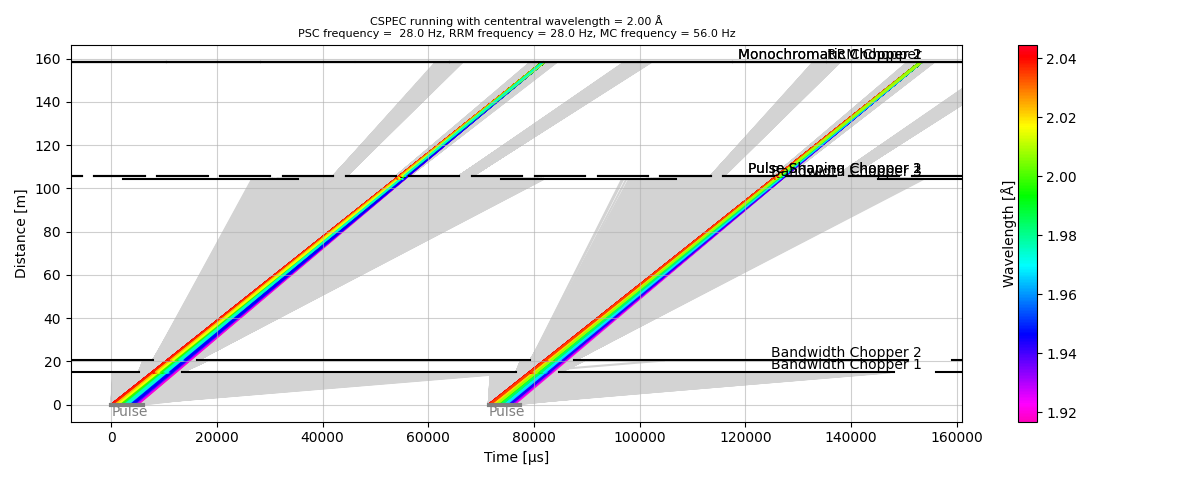

In [3]:
%matplotlib widget
import scipp as sc
from drcspec.instrument import Instrument
from drcspec.components.source import Source
import matplotlib.pyplot as plt

T_OFFSET = sc.scalar(1.7, unit="ms")
central_wavelength = sc.scalar(2.0, unit="Å")
f_M = sc.scalar(56.0, unit="Hz")
n: int = 2
phase_bw3 = sc.scalar(0.0, unit="deg")

cspec = Instrument(central_wavelength, f_M, n, phase_bw3, t_offset=T_OFFSET)
cspec.source = Source(facility="ess-cspec", neutrons=5_000_000, pulses=2)  # type: ignore
print(cspec)
res1 = cspec.run()

fig, ax = plt.subplots()
p = res1.plot(visible_rays=1_000_000, blocked_rays=50_000, ax=ax)

ax.set_title(str(cspec), fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()